Estimating Option Value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Load data from CSV
amazon = pd.read_csv('amazon_stock_data.csv', index_col='Date', parse_dates=True)
amazon

,close
Date,
2024-01-02,149.929993
2024-01-03,148.470001
2024-01-04,144.570007
2024-01-05,145.240005
2024-01-08,149.100006
...,...
2025-09-22,227.630005
2025-09-23,220.710007
2025-09-24,220.210007


Potentially interesting plot of Amazon closing prices from 2024-01-02 to 2025-09-26:


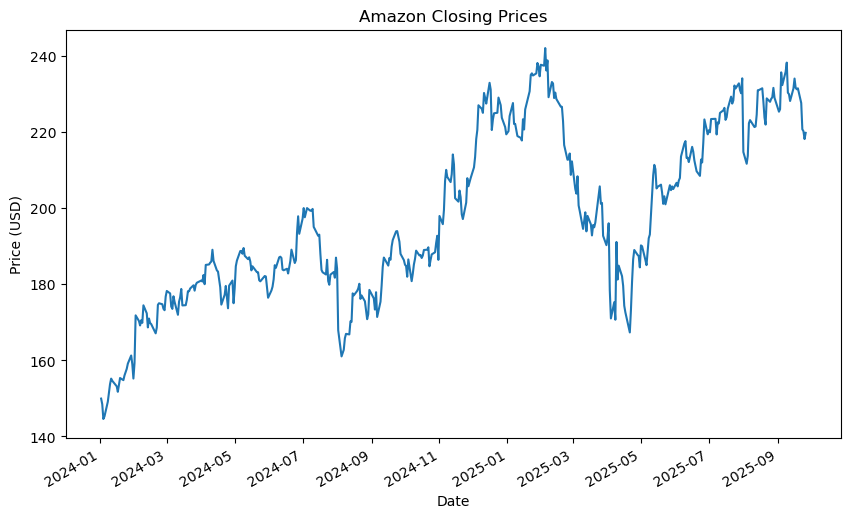

In [3]:
# Price plot
print(f'Potentially interesting plot of Amazon closing prices from {amazon.index.min().date()} to {amazon.index.max().date()}:')
amazon.close.plot(figsize=(10, 6))
plt.title('Amazon Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

In [4]:
# Using plotly history stock price line chart

fig = px.line(amazon, x=amazon.index, y='close', title='Amazon Closing Prices')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Price (USD)')
fig.show()


In [5]:
# Price changes
amazon['price_change'] = amazon['close'].diff()
amazon['return'] = np.log1p(amazon['close']).diff()
# Volatility returns 21 daily returns
amazon['volatility'] = amazon['return'].rolling(21).std()
# There are differences between change and return, especially for large price movements.
amazon

,close,price_change,return,volatility
Date,,,,
2024-01-02,149.929993,NaN,NaN,NaN
2024-01-03,148.470001,-1.459991,-0.009720,NaN
2024-01-04,144.570007,-3.899994,-0.026439,NaN
2024-01-05,145.240005,0.669998,0.004592,NaN
2024-01-08,149.100006,3.860001,0.026053,NaN
...,...,...,...,...
2025-09-22,227.630005,-3.849991,-0.016699,0.016765
2025-09-23,220.710007,-6.919998,-0.030735,0.016745
2025-09-24,220.210007,-0.500000,-0.002258,0.016738


Formula for estimating future stock price using Geometric Brownian Motion:
$$ FV = e^{(r - \frac{1}{2} \sigma^2) \frac{T}{N} + \sigma \sqrt{\frac{T}{N}} Z} $$

Where:
- $ FV $ = Future Value of the investment
- $ r $ = Risk-free interest rate
- $ \sigma $ = Volatility of the stock
- $ T $ = Time horizon for the investment (in years)
- $ N $ = Number of trading days in a year (typically 252)
- $ Z $ = Standard normal random variable


Current stock price: $219.78
Volatility (annualized): 26.81%
Risk-free interest rate: 5.00%
Estimated stock price after 21 days: $220.62 (mean of simulations)


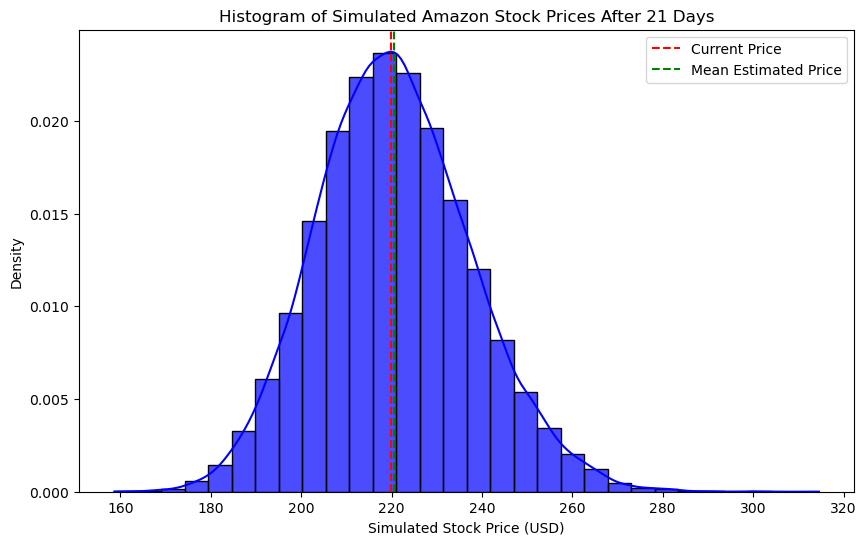

In [6]:
# Estimating an ending price for a fictitious stock option using Geometric Brownian Motion
current_price = amazon['close'].iloc[-1]  # Current stock price
# Get the annualized volatility from the Amazon DataFrame
volatility = amazon['volatility'].iloc[-1]* np.sqrt(252) # Annualized volatility
risk_free_rate = 0.05  # Annual risk-free interest rate (5%) (90-days T-bill)
time_horizon = 21
year = 252  # Trading days in a year
num_simulations = 50_000  # Number of simulations

# Simulate multiple possible ending prices
rng = np.random.default_rng()  # Random number generator for reproducibility
Z = rng.standard_normal(num_simulations)  # Generate random numbers for all simulations
# GBM formula to estimate future price
fv = (risk_free_rate - 0.5 * volatility**2) * (time_horizon / year) + (volatility * np.sqrt(time_horizon / year)) * Z  # Future value factor
estimated_price = current_price * np.exp(fv)
print(f'Current stock price: ${current_price:.2f}')
print(f'Volatility (annualized): {volatility:.2%}')
print(f'Risk-free interest rate: {risk_free_rate:.2%}')
print(f'Estimated stock price after {time_horizon} days: ${np.mean(estimated_price):.2f} (mean of simulations)')

# Plot histogram of simulated ending prices
plt.figure(figsize=(10, 6))
sns.histplot(estimated_price, bins=30, alpha=0.7, color='blue', edgecolor='black', kde=True, stat='density')
plt.title(f'Histogram of Simulated Amazon Stock Prices After {time_horizon} Days')
plt.xlabel('Simulated Stock Price (USD)')
plt.ylabel('Density')
plt.axvline(x=current_price, color='r', linestyle='--', label='Current Price')
plt.axvline(x=np.mean(estimated_price), color='g', linestyle='--', label='Mean Estimated Price')
plt.legend()
plt.show()

In [7]:
# Using Monte Carlo Method to simulate multiple possible ending prices 
def monte_carlo_simulation(S, K, vol, rfr, t_days, I, seed = None):
    '''
    S: Current stock price
    K: Strike price
    vol: Volatility
    rfr: Risk-free rate
    t: Time to expiration
    I: Number of simulations
    '''
    year = 252  # Trading days in a year
    T = t_days / year  # Time to expiration in years
    rng = np.random.default_rng(seed)  # Random number generator for reproducibility
    Z = rng.standard_normal(I//2)  # Generate random numbers
    Z = np.concatenate((Z, -Z))  # Antithetic variates for variance reduction
    St = S * np.exp((rfr - .5 * vol ** 2)* T + vol * np.sqrt(T) * Z)  # Simulated ending prices
    payoffs = np.maximum(St - K, 0.0)  # Call option payoffs
    discounted_payoffs = np.exp(-rfr * T) * payoffs  # Discounted average payoff vector
    price = discounted_payoffs.mean()
    stderr = discounted_payoffs.std(ddof=1) / np.sqrt(len(discounted_payoffs))  # Standard error
    return price, stderr

# Example usage
S = current_price  # Current stock price
K = current_price * 1.05  # Strike price (5% above current price)
vol = volatility  # Volatility (annualized)
rfr = 0.05  # Risk-free rate (5%)
t = 21  # Time to expiration (21 days)
I = 50_000  # Number of simulations
option_price, stderr = monte_carlo_simulation(S, K, vol, rfr, t, I, seed=100)
print(f'Estimated Call Option Price using Monte Carlo: ${option_price:.2f} +/- ${stderr:.2f} (95% CI = ${option_price - 1.96 * stderr:.2f} to ${option_price + 1.96 * stderr:.2f})')


Estimated Call Option Price using Monte Carlo: $3.03 +/- $0.03 (95% CI = $2.96 to $3.09)


Black-Scholes formula:$$ C = S N(d_1) - K e^{-rT} N(d_2) $$
Where:
- $ C $ = Call option price
- $ S $ = Current stock price
- $ K $ = Strike price of the option
- $ r $ = Risk-free interest rate
- $ T $ = Time to expiration (in years)
- $ N(d) $ = Cumulative distribution function of the standard normal distribution
- $ d_1 = \frac{1}{\sigma \sqrt{T}} \left[ \ln\left(\frac{S}{K}\right) + \left(r + \frac{\sigma^2}{2}\right) T \right] $
- $ d_2 = d_1 - \sigma \sqrt{T} $


In [8]:
# Import norm from scipy.stats
from scipy.stats import norm

# Using Black-Scholes formula to simulate multiple possible ending prices
def black_scholes(S, K, vol, rfr, t_days, I):
    '''
    S: Current stock price
    K: Strike price
    vol: Volatility
    rfr: Risk-free rate
    t: Time to expiration
    I: Number of simulations
    '''
    year = 252  # Trading days in a year
    T = t_days / year  # Time to expiration in years
    d1 = (np.log(S / K) + (rfr + 0.5 * vol ** 2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-rfr * T) * norm.cdf(d2)
    return call
# Example usage
S = current_price  # Current stock price
K = current_price * 1.05  # Strike price (5% above current price)
vol = volatility  # Volatility (annualized)
rfr = 0.05  # Risk-free rate (5%)
t = 21  # Time to expiration (21 days)
I = 50_000  # Number of simulations
option_price = black_scholes(S, K, vol, rfr, t, I)
print(f'Estimated Call Option Price using Black-Scholes: ${option_price:.2f}')


Estimated Call Option Price using Black-Scholes: $3.05


Current stock price: $219.78
Volatility (annualized): 26.81%
Risk-free interest rate: 5.00%
Estimated stock price after 21 days: $220.56 (mean of simulations)

Estimated Call Option Price using Monte Carlo: $3.03 +/- $0.03 (95% CI = $2.96 to $3.09)
Estimated Call Option Price using Black-Scholes: $3.05

Interpretation:
- The estimated call option price using both Monte Carlo simulation and the Black-Scholes formula is around $3.03 to $3.05.
- This suggests that, given the current stock price, volatility, and risk-free rate, the market would likely price a call option with a strike price of $220 and an expiration in 21 days at approximately $3.03 to $3.05.
- The risk neutral expected stock price after 21 days is estimated to be $220.56, indicating a slight expected increase from the current price of $219.78.
- Sigma is 36.81%, current price is $219.78: $219.78 * 0.2681 * sqrt(21/252) = $17.01 expected move in 21 days. Roughly 68% chance of a move greater than $17.01, up or down, in 21 days.
- K (Strike price (5% above current price)) + premium: $219.78 * 1.05 + $3.03 = $233.799 breakeven price at expiration. Need stock price above $233.799 at expiration to profit from the option in 21 days.

